# H1: High-Dimensional / High-Mode Scaling of Guided H-PID

This notebook implements the **H1** experiment block specified in
`merged_paper_plan_v7.tex`, Section *"Detailed New Final Experiment Block:
H1 High-Dimensional / High-Mode Scaling"*.

The goal is to demonstrate that Guided H-PID (LQ-GM-PID with $\sigma=0$)
scales gracefully in two directions beyond the 2D case studies of
`GuidedPID.pdf`:

1. ambient dimension $d$ (with fixed mode count $M$),
2. number of terminal modes $M$ (with fixed dimension $d$).

It uses

* a **delta source** $X_0=0$,
* a **simple fixed trunk guide** $\nu_t$ encoding only the shared corridor,
* a **small family of hand-designed matrix-valued $\beta_t$ protocols**
  (no inner optimization loop),
* a **hierarchical trunk / branch / local target GMM**.

The TMLR-facing question is:
> *Can a simple, interpretable guide potential organize coarse-to-fine
> multimodal transport in high dimension without expensive protocol
> optimization?*

H1 is split into three sub-blocks, in line with the plan:

* **H1-A: dimension scaling** at fixed $M=8$, sweeping $d\in\{4,8,16,32\}$
* **H1-B: mode scaling** at fixed $d=16$, sweeping $M\in\{2,4,8,16\}$
* **H1-C: representative qualitative views** — PCA / selected-coordinate
  projections for one $(d,M)$ point.

All structural objects come from the `lqgm_pid` API:
`GaussianMixture`, `MatrixPWCProtocol`, `TimeDomain`, `LQGMPID`,
`exact_marginal_gmm`. No lower-level coefficient code is touched.

In [1]:
from __future__ import annotations

import math
import os
import sys
import time
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Optional, Sequence, Tuple

import matplotlib.pyplot as plt
import numpy as np
import torch

# Robust project-root discovery (works as script and after jupytext --to notebook)
if "__file__" in globals():
    ROOT = Path(__file__).resolve().parents[1]
else:
    ROOT = Path.cwd().resolve()
    if not (ROOT / "lqgm_pid").exists():
        for parent in [ROOT] + list(ROOT.parents):
            if (parent / "lqgm_pid").exists():
                ROOT = parent
                break
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from experiments.common import (
    default_device,
    default_dtype,
    ensure_dir,
    save_csv,
    save_metrics_json,
    set_seed,
)
from lqgm_pid import (
    GaussianMixture,
    LQGMPID,
    MatrixPWCProtocol,
    TimeDomain,
)
from lqgm_pid.density import exact_marginal_gmm

## Configuration

All constants follow the *"Suggested concrete parameter values"* from
the plan. The fixed K=12 partition is chosen so that the branch-release
time $t_*=0.5$ falls exactly on a breakpoint.

In [2]:
SEED = 20260101
DEVICE = default_device()
DTYPE = default_dtype()

OUTDIR = ensure_dir(str(ROOT / "results" / "H1_highdim_scaling"))
FIGDIR = ensure_dir(str(ROOT / "figs"))

# Time discretization
K_INTERVALS = 12             # PWC intervals; even, so t*=0.5 is a break
T_STAR = 0.5                 # branch-release time
TD_EPS = 1e-3
BC_EPS = 1e-6

# EM simulation grid
N_STEPS_EM = 600             # Euler-Maruyama steps
B_SIM = 1024                 # particles per protocol per scenario

# Density-grid for trunk/branch/local subspace variance
N_DENSITY_TIMES = 21         # times for exact-marginal subspace tracking

# Target geometry  (plan: a=3.0, b=1.0, c=0.35)
TRUNK_AMP = 3.0
BRANCH_AMP = 1.0
LOCAL_AMP = 0.35

# Target covariance scales (mild anisotropy by block)
SIGMA_TRUNK = 0.10           # tight in trunk block
SIGMA_BRANCH = 0.18          # moderate in branch block
SIGMA_LOCAL = 0.25           # mild in local block

# Protocol parameters
LAMBDA_ISO = 2.0             # B0 isotropic baseline
LAMBDA_T = 0.5               # tangential / trunk stiffness for B1, B2
LAMBDA_PERP = 4.0            # transverse stiffness for B1
LAMBDA_B = 6.0               # branch stiffness on [0, t*] for B2
LAMBDA_B_TILDE = 1.0         # branch stiffness on (t*, 1] for B2  (release)
LAMBDA_L = 4.0               # local stiffness for B2

# Sweep axes
DIMS_A = [4, 8, 16, 32]      # H1-A: dimension sweep, fixed M=8
M_A_FIXED = 8
M_B = [2, 4, 8, 16]          # H1-B: mode sweep
D_B_FIXED = 16

# Snapshot times for subspace tracking and PCA panels
TIME_GRID = np.linspace(0.05, 0.95, N_DENSITY_TIMES)

# Branching-time threshold: fraction of terminal branch-block variance
BRANCH_THRESHOLD_FRAC = 0.50

set_seed(SEED)
print(f"Device : {DEVICE}")
print(f"Output : {OUTDIR}")
print(f"Figures: {FIGDIR}")

Device : cpu
Output : /Users/chertkov/Dropbox/Apps/Overleaf/LQ-GM-PID/guided-plus/results/H1_highdim_scaling
Figures: /Users/chertkov/Dropbox/Apps/Overleaf/LQ-GM-PID/guided-plus/figs


## Coordinate-block layout

The plan prescribes three coordinate blocks: trunk / branch / local.
We always keep the trunk block 2-dimensional (so we can render a 2D
trunk-plane projection in H1-C); the branch block is 2-dimensional for
small $d$ and 4-dimensional once $d\ge 16$; the rest is local.

In [3]:
@dataclass
class BlockLayout:
    """Trunk / branch / local coordinate split for an ambient dim d."""
    d: int
    d_T: int                 # trunk
    d_B: int                 # branch
    d_L: int                 # local

    @property
    def trunk_idx(self) -> slice: return slice(0, self.d_T)
    @property
    def branch_idx(self) -> slice: return slice(self.d_T, self.d_T + self.d_B)
    @property
    def local_idx(self) -> slice: return slice(self.d_T + self.d_B, self.d)

    def __post_init__(self):
        assert self.d_T + self.d_B + self.d_L == self.d, \
            f"block sizes ({self.d_T},{self.d_B},{self.d_L}) must sum to d={self.d}"


def make_block_layout(d: int) -> BlockLayout:
    """Plan's recommended block layouts.

    d=4   : trunk 1 / branch 2 / local 1
            (the plan does not specify d=4; we shrink the trunk to a line
            so that all three blocks remain non-empty and local refinement
            still makes sense)
    d=8   : trunk 2 / branch 2 / local 4
    d=16  : trunk 2 / branch 4 / local 10
    d=32  : trunk 2 / branch 4 / local 26
    """
    if d == 4:
        return BlockLayout(d=4, d_T=1, d_B=2, d_L=1)
    if d == 8:
        return BlockLayout(d=8, d_T=2, d_B=2, d_L=4)
    if d >= 16:
        return BlockLayout(d=d, d_T=2, d_B=4, d_L=d - 6)
    raise ValueError(f"Unsupported d={d}")

## Hierarchical trunk-and-branch target GMM

Each terminal mode is indexed by $(b,\ell)$ with branch index
$b\in\{1,\dots,B\}$ and local index $\ell\in\{1,\dots,L\}$, total
$M = B \cdot L$. The mode mean is

$$
  \mu_{b,\ell} = \mu^{\mathrm{trunk}} + \mu_b^{\mathrm{branch}}
               + \mu_{b,\ell}^{\mathrm{local}}.
$$

Branch offsets live only in the branch block; local offsets only in
the local block. Covariances are diagonal with mild anisotropy by
block (tighter in trunk, moderate in branch, mild in local).

In [4]:
def _branch_codebook(d_B: int, B: int, amp: float,
                     dtype: torch.dtype, device) -> torch.Tensor:
    """Construct B branch-offset vectors of dimension d_B with amplitude amp.

    For B<=4 we use sign patterns in the first two branch coords.
    For larger B we tile via additional sign patterns or coordinate axes.
    """
    if d_B < 2:
        raise ValueError("Need at least two branch coordinates")
    out = torch.zeros(B, d_B, dtype=dtype, device=device)
    if B == 1:
        out[0, 0] = amp
        return out
    if B == 2:
        out[0, 0], out[1, 0] = +amp, -amp
        return out
    # Up to 4 branches: corners of a square in the first two branch coords
    corners = torch.tensor(
        [[+1, +1], [+1, -1], [-1, +1], [-1, -1]],
        dtype=dtype, device=device,
    )
    n_corners = min(B, 4)
    out[:n_corners, :2] = amp * corners[:n_corners]
    if B <= 4:
        return out
    # Beyond 4: extend with axis-aligned offsets in additional branch coords
    for k in range(4, B):
        c = (k - 4) % d_B
        s = +amp if (k - 4) // d_B % 2 == 0 else -amp
        out[k, c] = s
    return out


def _local_codebook(d_L: int, L: int, amp: float,
                    dtype: torch.dtype, device) -> torch.Tensor:
    """Construct L local-offset vectors of dimension d_L with amplitude amp.

    L=1 -> zero (no local refinement). For L>=2 we use one-coordinate
    sign patterns in the local block.
    """
    out = torch.zeros(L, d_L, dtype=dtype, device=device)
    if L == 1:
        return out
    if d_L == 0:
        # No local block (as in d=4).  All L>1 collapse onto the same point;
        # callers should ensure (B*L) is matched to layout.
        return out
    for k in range(L):
        c = k % d_L
        s = +amp if k // d_L % 2 == 0 else -amp
        out[k, c] = s
    return out


def make_hierarchical_target(
    *,
    d: int,
    B_branches: int,
    L_locals: int,
    layout: BlockLayout,
    trunk_amp: float = TRUNK_AMP,
    branch_amp: float = BRANCH_AMP,
    local_amp: float = LOCAL_AMP,
    sigma_trunk: float = SIGMA_TRUNK,
    sigma_branch: float = SIGMA_BRANCH,
    sigma_local: float = SIGMA_LOCAL,
    dtype: torch.dtype = DTYPE,
    device=DEVICE,
) -> Tuple[GaussianMixture, torch.Tensor]:
    """Build a hierarchical trunk-and-branch GMM with M = B_branches * L_locals modes.

    Returns
    -------
    target : GaussianMixture
    trunk_mean_full : (d,)  the common trunk displacement mu_trunk lifted to R^d
    """
    M = B_branches * L_locals

    # Trunk displacement: place along coordinate 0
    mu_trunk = torch.zeros(d, dtype=dtype, device=device)
    mu_trunk[0] = trunk_amp

    branch_offsets = _branch_codebook(layout.d_B, B_branches, branch_amp,
                                      dtype, device)             # (B, d_B)
    local_offsets  = _local_codebook(layout.d_L, L_locals, local_amp,
                                     dtype, device)              # (L, d_L)

    # Build per-mode means
    means = torch.zeros(M, d, dtype=dtype, device=device)
    for b in range(B_branches):
        for l in range(L_locals):
            m = b * L_locals + l
            means[m] = mu_trunk
            means[m, layout.branch_idx] = means[m, layout.branch_idx] + branch_offsets[b]
            if layout.d_L > 0:
                means[m, layout.local_idx] = means[m, layout.local_idx] + local_offsets[l]

    # Block-diagonal covariances  (mild anisotropy by block, equal across modes)
    diag = torch.empty(d, dtype=dtype, device=device)
    diag[layout.trunk_idx]  = sigma_trunk  ** 2
    diag[layout.branch_idx] = sigma_branch ** 2
    if layout.d_L > 0:
        diag[layout.local_idx] = sigma_local ** 2
    base_cov = torch.diag(diag)
    covs = base_cov.unsqueeze(0).expand(M, d, d).clone()

    weights = torch.full((M,), 1.0 / M, dtype=dtype, device=device)
    target = GaussianMixture(weights=weights, means=means, covs=covs)
    return target, mu_trunk

## Trunk guide $\nu_t$ — Version B (fast-then-hold)

We use the recommended Version B from the plan:

$$
  \nu_t = \begin{cases}
    2t\,\mu^{\mathrm{trunk}}, & 0 \le t \le 1/2,\\
    \mu^{\mathrm{trunk}},     & 1/2 < t \le 1.
  \end{cases}
$$

Because the partition is uniform with $K=12$ and $t_*=1/2$ is exactly the
midpoint break, every interval midpoint $t^\star_k$ lies cleanly on one
side of $t_*$ and the PWC sample of $\nu_t$ is unambiguous.

In [5]:
def make_breaks(K: int = K_INTERVALS, *, dtype=DTYPE, device=DEVICE) -> torch.Tensor:
    return torch.linspace(0.0, 1.0, K + 1, dtype=dtype, device=device)


def fast_then_hold_guide(t: torch.Tensor, mu_trunk: torch.Tensor) -> torch.Tensor:
    """Vectorised Version B guide. Returns (..., d)."""
    t = t.clamp(0.0, 1.0)
    s = torch.where(t <= 0.5, 2.0 * t, torch.ones_like(t))     # (..,)
    return s.unsqueeze(-1) * mu_trunk                          # (.., d)


def make_nu_pwc(breaks: torch.Tensor, mu_trunk: torch.Tensor) -> torch.Tensor:
    """Sample Version B guide at interval midpoints. Returns (K, d)."""
    t_mid = 0.5 * (breaks[:-1] + breaks[1:])
    return fast_then_hold_guide(t_mid, mu_trunk)

## Matrix-valued $\beta_t$ protocols

Three protocols are constructed:

* **B0 — isotropic constant baseline:** $\beta_t = \lambda I$.
* **B1 — anisotropic corridor:** trunk block uses $\lambda_T$, all
  orthogonal directions use $\lambda_\perp$. This produces a
  high-dimensional tube around the trunk.
* **B2 — branch-release (recommended main comparator):** time-dependent
  block-diagonal schedule with branch coordinates held tight on
  $[0, t_*]$ and released on $(t_*, 1]$. The trunk and local blocks have
  constant stiffnesses across time.

In [6]:
def _block_diag_beta(
    layout: BlockLayout,
    *,
    lambda_T: float,
    lambda_B: float,
    lambda_L: float,
    dtype=DTYPE,
    device=DEVICE,
) -> torch.Tensor:
    """Block-diagonal SPD matrix sized (d, d) with given block stiffnesses."""
    d = layout.d
    diag = torch.empty(d, dtype=dtype, device=device)
    diag[layout.trunk_idx]  = lambda_T
    diag[layout.branch_idx] = lambda_B
    if layout.d_L > 0:
        diag[layout.local_idx] = lambda_L
    return torch.diag(diag)


def make_beta_B0(K: int, layout: BlockLayout,
                 *, lam: float = LAMBDA_ISO,
                 dtype=DTYPE, device=DEVICE) -> torch.Tensor:
    """B0 isotropic constant: beta_k = lam * I_d for all k."""
    I = torch.eye(layout.d, dtype=dtype, device=device)
    return (lam * I).unsqueeze(0).expand(K, layout.d, layout.d).clone()


def make_beta_B1(K: int, layout: BlockLayout,
                 *, lambda_T: float = LAMBDA_T,
                 lambda_perp: float = LAMBDA_PERP,
                 dtype=DTYPE, device=DEVICE) -> torch.Tensor:
    """B1 anisotropic corridor: trunk loose, everything else tight, constant in t."""
    base = _block_diag_beta(layout,
                            lambda_T=lambda_T,
                            lambda_B=lambda_perp,
                            lambda_L=lambda_perp,
                            dtype=dtype, device=device)
    return base.unsqueeze(0).expand(K, layout.d, layout.d).clone()


def make_beta_B2(K: int, breaks: torch.Tensor, layout: BlockLayout,
                 *, t_star: float = T_STAR,
                 lambda_T: float = LAMBDA_T,
                 lambda_B: float = LAMBDA_B,
                 lambda_B_tilde: float = LAMBDA_B_TILDE,
                 lambda_L: float = LAMBDA_L,
                 dtype=DTYPE, device=DEVICE) -> torch.Tensor:
    """B2 branch-release: branch block tight on [0,t*], loose on (t*,1].

    The trunk and local blocks use constant stiffness throughout.
    """
    t_mid = 0.5 * (breaks[:-1] + breaks[1:])
    out = torch.empty(K, layout.d, layout.d, dtype=dtype, device=device)
    for k in range(K):
        lam_b_k = lambda_B if t_mid[k].item() <= t_star else lambda_B_tilde
        out[k] = _block_diag_beta(layout,
                                  lambda_T=lambda_T,
                                  lambda_B=lam_b_k,
                                  lambda_L=lambda_L,
                                  dtype=dtype, device=device)
    return out


def assemble_protocol(
    *,
    layout: BlockLayout,
    target: GaussianMixture,
    mu_trunk: torch.Tensor,
    beta: torch.Tensor,
    K: int = K_INTERVALS,
    td_eps: float = TD_EPS,
    dtype=DTYPE,
    device=DEVICE,
) -> MatrixPWCProtocol:
    breaks = make_breaks(K, dtype=dtype, device=device)
    nu = make_nu_pwc(breaks, mu_trunk)                        # (K, d)
    sigma = torch.zeros(K, layout.d, layout.d, dtype=dtype, device=device)
    return MatrixPWCProtocol(
        breaks=breaks, sigma=sigma, beta=beta, nu=nu,
        time_domain=TimeDomain(eps=td_eps),
    )

## Sampling helpers

We need a small i.i.d. sampler for the target GMM (for terminal-fidelity
diagnostics) and a thin wrapper around `LQGMPID.simulate` to record
sample-level subspace traces.

In [7]:
def sample_gmm_iid(gmm: GaussianMixture, n: int, *, seed: int = 0,
                   dtype=DTYPE, device=DEVICE) -> torch.Tensor:
    """Sample n i.i.d. points from a Gaussian mixture. Returns (n, d)."""
    gmm = gmm.to(device=device, dtype=dtype)
    gen = torch.Generator(device=torch.device(str(device)) if str(device) != "cpu"
                          else torch.device("cpu"))
    gen.manual_seed(seed)
    comp = torch.multinomial(gmm.weights, num_samples=n,
                             replacement=True, generator=gen)
    d = gmm.d
    out = torch.empty(n, d, dtype=dtype, device=device)
    for m in range(gmm.M):
        idx = torch.where(comp == m)[0]
        if idx.numel() == 0:
            continue
        chol = torch.linalg.cholesky(gmm.covs[m])
        z = torch.randn((idx.numel(), d), generator=gen,
                        dtype=dtype, device=device)
        out[idx] = gmm.means[m] + z @ chol.T
    return out


def simulate_paths(pid: LQGMPID, *, B: int = B_SIM,
                   n_steps: int = N_STEPS_EM, seed: int = SEED) -> Tuple[torch.Tensor, torch.Tensor]:
    """Wrapper around pid.simulate that returns CPU tensors (T,) and (T,B,d)."""
    sim = pid.simulate(B=B, n_steps=n_steps, seed=seed,
                       dtype=pid.protocol.dtype,
                       device=str(pid.protocol.device))
    return sim.times.detach().cpu(), sim.traj.detach().cpu()

## Diagnostics

Per the plan, H1 is reported through quantitative diagnostics rather
than trajectory plots. The five primary diagnostics are:

1. **Mode-weight error** — soft-assign empirical $X_1$ to mixture
   components via target responsibilities, sum to recover empirical
   weight vector, compare to $\pi_k=1/M$ with $\ell_\infty$ and TV
   distance.
2. **Guide-cost adherence** — $\int_0^1 \mathbb{E}\|X_t - \nu_t\|^2\,dt$
   via the sampled trajectories.
3. **Branching time** — first time the trace of the empirical branch-
   block covariance exceeds a fraction of its terminal value.
4. **Subspace variance decomposition** — `tr(Var_block(X_t))` over time
   for trunk / branch / local blocks. We compute this *both* from the
   exact marginal (closed-form) and from the empirical paths, as a
   cross-check.
5. **Runtime** — sweep precompute time and per-control wall time.

In [8]:
def soft_mode_weights(x_T: torch.Tensor, target: GaussianMixture) -> torch.Tensor:
    """Soft-assign empirical samples x_T to GMM components via target responsibilities.

    Returns (M,) normalized empirical mixture weights.
    """
    x_T = x_T.to(device=target.weights.device, dtype=target.weights.dtype)
    M = target.M
    d = target.d
    n = x_T.shape[0]
    log_pi = torch.log(target.weights)                                  # (M,)

    # Cholesky of each component covariance for numerically stable logpdf
    # log N(x; m_k, S_k) = -0.5 ((x-m_k)^T S_k^{-1} (x-m_k))
    #                     - 0.5 d log(2π) - sum log diag(L_k)
    out = torch.empty(M, n, dtype=x_T.dtype, device=x_T.device)
    const = -0.5 * d * math.log(2.0 * math.pi)
    for m in range(M):
        L = torch.linalg.cholesky(target.covs[m])
        diff = x_T - target.means[m]                                    # (n, d)
        sol = torch.linalg.solve_triangular(L, diff.T, upper=False)     # (d, n)
        quad = (sol ** 2).sum(dim=0)                                    # (n,)
        logdet = 2.0 * torch.log(torch.diagonal(L)).sum()
        out[m] = log_pi[m] + const - 0.5 * logdet - 0.5 * quad
    log_resp = out - torch.logsumexp(out, dim=0, keepdim=True)          # (M, n)
    resp = torch.exp(log_resp)                                          # (M, n)
    w_emp = resp.mean(dim=1)                                            # (M,)
    return w_emp


def mode_weight_error(x_T: torch.Tensor, target: GaussianMixture) -> Dict[str, float]:
    """Mode-weight error metrics."""
    w_emp = soft_mode_weights(x_T, target).cpu()
    w_tar = target.weights.cpu()
    return {
        "linf_weight_err": float((w_emp - w_tar).abs().max().item()),
        "tv_weight_err":   float(0.5 * (w_emp - w_tar).abs().sum().item()),
        "min_weight_emp":  float(w_emp.min().item()),
        "max_weight_emp":  float(w_emp.max().item()),
    }


def guide_cost_from_paths(traj: torch.Tensor, times: torch.Tensor,
                          mu_trunk: torch.Tensor) -> float:
    """Trapezoidal estimate of A_guide = \\int E||X_t - nu_t||^2 dt."""
    times = times.to(traj.dtype)
    nu_t = fast_then_hold_guide(times, mu_trunk.to(traj.dtype).cpu())   # (T, d)
    diff = traj - nu_t.unsqueeze(1)                                     # (T, B, d)
    sqd  = (diff ** 2).sum(dim=-1).mean(dim=1)                          # (T,)
    return float(torch.trapz(sqd, times).item())


def subspace_traces_from_paths(traj: torch.Tensor, layout: BlockLayout
                               ) -> Dict[str, torch.Tensor]:
    """Empirical tr(Var) per block, per time. Returns dict block -> (T,)."""
    T = traj.shape[0]
    out: Dict[str, torch.Tensor] = {}
    for name, sl in [("trunk",  layout.trunk_idx),
                     ("branch", layout.branch_idx),
                     ("local",  layout.local_idx)]:
        if sl.stop - sl.start == 0:
            out[name] = torch.zeros(T, dtype=traj.dtype)
            continue
        sub = traj[..., sl]                                             # (T, B, db)
        var_t = sub.var(dim=1, unbiased=False).sum(dim=-1)              # (T,)
        out[name] = var_t
    return out


def subspace_traces_from_density(pid: LQGMPID, layout: BlockLayout,
                                 t_grid: np.ndarray) -> Dict[str, np.ndarray]:
    """Closed-form tr(Var) per block from the exact marginal GMM."""
    out_T = np.zeros_like(t_grid)
    out_B = np.zeros_like(t_grid)
    out_L = np.zeros_like(t_grid)
    for i, t in enumerate(t_grid):
        gmm = exact_marginal_gmm(pid, float(t))
        w = gmm["weights"].cpu().numpy()                                # (M,)
        mu = gmm["means"].cpu().numpy()                                 # (M, d)
        Sigma = gmm["covs"].cpu().numpy()                               # (M, d, d)
        # Total mean and covariance of the mixture
        mu_bar = (w[:, None] * mu).sum(axis=0)                          # (d,)
        # E[xx^T] = sum_k w_k (Sigma_k + mu_k mu_k^T)
        EXX = np.einsum("k,kij->ij", w, Sigma) \
            + np.einsum("k,ki,kj->ij", w, mu, mu)
        Cov = EXX - np.outer(mu_bar, mu_bar)
        out_T[i] = np.trace(Cov[layout.trunk_idx,  layout.trunk_idx])
        out_B[i] = np.trace(Cov[layout.branch_idx, layout.branch_idx])
        if layout.d_L > 0:
            out_L[i] = np.trace(Cov[layout.local_idx,  layout.local_idx])
    return {"trunk": out_T, "branch": out_B, "local": out_L}


def branching_time(branch_var_t: np.ndarray, t_grid: np.ndarray,
                   *, frac: float = BRANCH_THRESHOLD_FRAC) -> Optional[float]:
    """First time at which branch-block variance exceeds frac * terminal value.

    Returns None if no time meets the threshold (e.g. branch block is collapsed).
    """
    if branch_var_t.size == 0:
        return None
    target_val = frac * branch_var_t[-1]
    if target_val <= 1e-12:
        return None
    above = np.where(branch_var_t >= target_val)[0]
    if above.size == 0:
        return None
    return float(t_grid[above[0]])

## One scenario runner

Given $(d,M,B_\text{branches},L_\text{locals})$ and a protocol family,
build target + protocol + controller, simulate, and return the full
diagnostic bundle. Times are wall-clock CPU seconds.

In [9]:
PROTOCOL_NAMES = ["B0", "B1", "B2"]


def run_single_scenario(
    *,
    d: int,
    B_branches: int,
    L_locals: int,
    protocols: Sequence[str] = PROTOCOL_NAMES,
    seed: int = SEED,
    B_sim: int = B_SIM,
    n_steps_em: int = N_STEPS_EM,
    K: int = K_INTERVALS,
    dtype=DTYPE,
    device=DEVICE,
) -> Dict:
    """Run B0/B1/B2 for one (d, M=B*L) scenario. Returns nested dict of metrics."""
    layout = make_block_layout(d)
    target, mu_trunk = make_hierarchical_target(
        d=d, B_branches=B_branches, L_locals=L_locals, layout=layout,
        dtype=dtype, device=device,
    )
    M = target.M
    x0 = torch.zeros(d, dtype=dtype, device=device)

    # Reference target sample for terminal Wasserstein-style checks (size-matched)
    target_samples = sample_gmm_iid(target, B_sim, seed=seed + 7,
                                    dtype=dtype, device=device).cpu()

    # Build the three beta protocols
    breaks = make_breaks(K, dtype=dtype, device=device)
    beta_makers = {
        "B0": lambda: make_beta_B0(K, layout, dtype=dtype, device=device),
        "B1": lambda: make_beta_B1(K, layout, dtype=dtype, device=device),
        "B2": lambda: make_beta_B2(K, breaks, layout, dtype=dtype, device=device),
    }

    out: Dict = {
        "d": d, "M": M, "B_branches": B_branches, "L_locals": L_locals,
        "layout": {"d_T": layout.d_T, "d_B": layout.d_B, "d_L": layout.d_L},
        "protocols": {},
    }

    for name in protocols:
        beta = beta_makers[name]()
        protocol = assemble_protocol(
            layout=layout, target=target, mu_trunk=mu_trunk, beta=beta,
            K=K, dtype=dtype, device=device,
        )
        pid = LQGMPID(protocol=protocol, target=target, x0=x0, bc_eps=BC_EPS)

        t0 = time.perf_counter()
        pid.precompute()
        t_pre = time.perf_counter() - t0

        # Simulation
        t0 = time.perf_counter()
        times, traj = simulate_paths(pid, B=B_sim, n_steps=n_steps_em, seed=seed)
        t_sim = time.perf_counter() - t0

        # Subspace decomposition (empirical)
        traces_emp = subspace_traces_from_paths(traj, layout)

        # Subspace decomposition (closed form)
        traces_dens = subspace_traces_from_density(pid, layout, TIME_GRID)

        # Branching-time statistic — preferred from empirical (closer to plan's
        # description of a "data-driven time"); also reported from density
        t_brk_emp = branching_time(
            traces_emp["branch"].numpy(), times.numpy(),
            frac=BRANCH_THRESHOLD_FRAC,
        )
        t_brk_dens = branching_time(
            traces_dens["branch"], TIME_GRID,
            frac=BRANCH_THRESHOLD_FRAC,
        )

        # Terminal diagnostics
        x_T = traj[-1]
        mw_err = mode_weight_error(x_T, target)
        m_emp = x_T.mean(dim=0)
        m_tar = target_samples.mean(dim=0)
        mean_err = float(torch.linalg.norm(m_emp - m_tar).item())

        # Guide adherence integral
        a_guide = guide_cost_from_paths(traj, times, mu_trunk)

        out["protocols"][name] = {
            "metrics": {
                **mw_err,
                "mean_l2_error": mean_err,
                "guide_cost":    a_guide,
                "branch_time_emp":  t_brk_emp,
                "branch_time_dens": t_brk_dens,
                "wallclock_precompute_s": t_pre,
                "wallclock_simulate_s":   t_sim,
            },
            # Lightweight trajectories kept only for H1-C qualitative panels
            "subspace_emp_times": times.numpy(),
            "subspace_emp": {k: v.numpy() for k, v in traces_emp.items()},
            "subspace_dens_times": TIME_GRID,
            "subspace_dens": {k: v for k, v in traces_dens.items()},
        }

    return out, target, mu_trunk, layout

# H1-A — Dimension scaling at fixed multimodality

We fix $M=8$ and sweep $d\in\{4,8,16,32\}$. The fixed mode count $M=8$
is decomposed as $B=4$ branches with $L=2$ locals per branch (matching
the plan's "convenient hierarchy").

In [10]:
B_BRANCHES_A, L_LOCALS_A = 4, 2     # M = 8

results_A: List[Dict] = []
for d in DIMS_A:
    print(f"\n[H1-A] d={d}, M={M_A_FIXED}")
    res, _, _, _ = run_single_scenario(
        d=d, B_branches=B_BRANCHES_A, L_locals=L_LOCALS_A,
    )
    results_A.append(res)
    for name in PROTOCOL_NAMES:
        m = res["protocols"][name]["metrics"]
        print(f"  {name}: tv_w={m['tv_weight_err']:.4f}  "
              f"A_guide={m['guide_cost']:.3f}  "
              f"t_brk_emp={m['branch_time_emp']}  "
              f"pre={m['wallclock_precompute_s']:.3f}s  "
              f"sim={m['wallclock_simulate_s']:.3f}s")

# Persist raw results for later analysis / paper tables
save_metrics_json(os.path.join(OUTDIR, "H1A_dimension_sweep.json"),
                  {"results": [
                      {**r, "protocols": {
                          k: {"metrics": v["metrics"]}
                          for k, v in r["protocols"].items()
                      }} for r in results_A
                  ]})


[H1-A] d=4, M=8
  B0: tv_w=0.0194  A_guide=1.741  t_brk_emp=0.66  pre=0.054s  sim=1.340s
  B1: tv_w=0.0236  A_guide=1.777  t_brk_emp=0.755  pre=0.015s  sim=1.289s
  B2: tv_w=0.0211  A_guide=1.873  t_brk_emp=0.6583333333333334  pre=0.015s  sim=1.271s

[H1-A] d=8, M=8
  B0: tv_w=0.0248  A_guide=2.384  t_brk_emp=0.6533333333333334  pre=0.014s  sim=1.547s
  B1: tv_w=0.0234  A_guide=2.384  t_brk_emp=0.7533333333333333  pre=0.015s  sim=1.540s
  B2: tv_w=0.0308  A_guide=2.480  t_brk_emp=0.6533333333333334  pre=0.016s  sim=1.630s

[H1-A] d=16, M=8
  B0: tv_w=0.0607  A_guide=3.673  t_brk_emp=0.3916666666666666  pre=0.020s  sim=2.851s
  B1: tv_w=0.0518  A_guide=3.539  t_brk_emp=0.5083333333333333  pre=0.024s  sim=2.724s
  B2: tv_w=0.0575  A_guide=3.647  t_brk_emp=0.46166666666666667  pre=0.021s  sim=2.657s

[H1-A] d=32, M=8
  B0: tv_w=0.0460  A_guide=6.314  t_brk_emp=0.425  pre=0.033s  sim=5.951s
  B1: tv_w=0.0455  A_guide=5.925  t_brk_emp=0.5983333333333334  pre=0.031s  sim=5.955s
  B2: tv_w=0

## H1-A panels — mode-weight error, guide cost, branching time, runtime

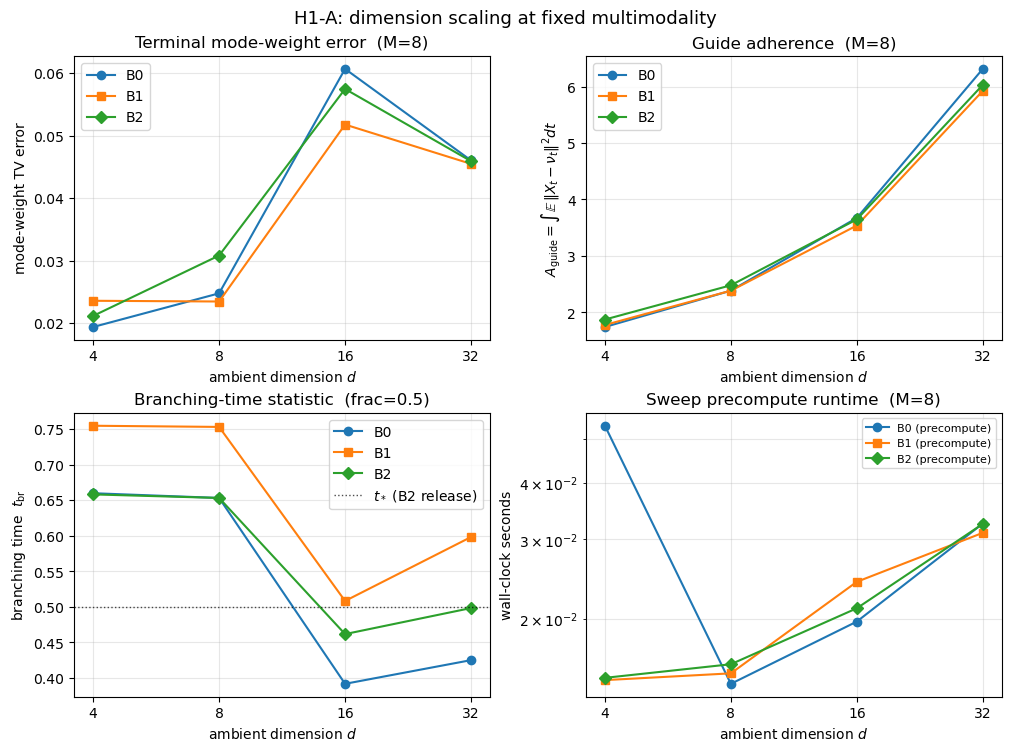

In [11]:
def _series(results, name, key):
    return np.array([r["protocols"][name]["metrics"][key]
                     if r["protocols"][name]["metrics"][key] is not None
                     else np.nan
                     for r in results])

fig, axes = plt.subplots(2, 2, figsize=(10.0, 7.4), constrained_layout=True)
xs = np.array(DIMS_A)

ax = axes[0, 0]
for name, mark in zip(PROTOCOL_NAMES, ["o", "s", "D"]):
    ax.plot(xs, _series(results_A, name, "tv_weight_err"),
            marker=mark, label=name)
ax.set_xscale("log", base=2); ax.set_xticks(xs); ax.set_xticklabels(xs)
ax.set_xlabel("ambient dimension $d$")
ax.set_ylabel("mode-weight TV error")
ax.set_title(f"Terminal mode-weight error  (M={M_A_FIXED})")
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[0, 1]
for name, mark in zip(PROTOCOL_NAMES, ["o", "s", "D"]):
    ax.plot(xs, _series(results_A, name, "guide_cost"),
            marker=mark, label=name)
ax.set_xscale("log", base=2); ax.set_xticks(xs); ax.set_xticklabels(xs)
ax.set_xlabel("ambient dimension $d$")
ax.set_ylabel(r"$A_{\mathrm{guide}}=\int \mathbb{E}\,\|X_t-\nu_t\|^2 dt$")
ax.set_title(f"Guide adherence  (M={M_A_FIXED})")
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1, 0]
for name, mark in zip(PROTOCOL_NAMES, ["o", "s", "D"]):
    ax.plot(xs, _series(results_A, name, "branch_time_emp"),
            marker=mark, label=name)
ax.axhline(T_STAR, color="k", ls=":", lw=1, alpha=0.7,
           label=r"$t_*$ (B2 release)")
ax.set_xscale("log", base=2); ax.set_xticks(xs); ax.set_xticklabels(xs)
ax.set_xlabel("ambient dimension $d$")
ax.set_ylabel("branching time  $t_{\\mathrm{br}}$")
ax.set_title(f"Branching-time statistic  (frac={BRANCH_THRESHOLD_FRAC})")
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1, 1]
for name, mark in zip(PROTOCOL_NAMES, ["o", "s", "D"]):
    ax.plot(xs, _series(results_A, name, "wallclock_precompute_s"),
            marker=mark, label=f"{name} (precompute)")
ax.set_xscale("log", base=2); ax.set_xticks(xs); ax.set_xticklabels(xs)
ax.set_yscale("log")
ax.set_xlabel("ambient dimension $d$")
ax.set_ylabel("wall-clock seconds")
ax.set_title(f"Sweep precompute runtime  (M={M_A_FIXED})")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, which="both")

fig.suptitle("H1-A: dimension scaling at fixed multimodality", fontsize=13)
fig.savefig(os.path.join(FIGDIR, "H1A_dimension_scaling.pdf"))
plt.show()

## H1-A subspace variance traces  (one row per $d$)

The subspace decomposition exposes the coarse-to-fine structure that
the plan singles out as "especially valuable." We show closed-form
values from `exact_marginal_gmm` (solid) overlaid with empirical
estimates from the EM paths (dashed) for each protocol.

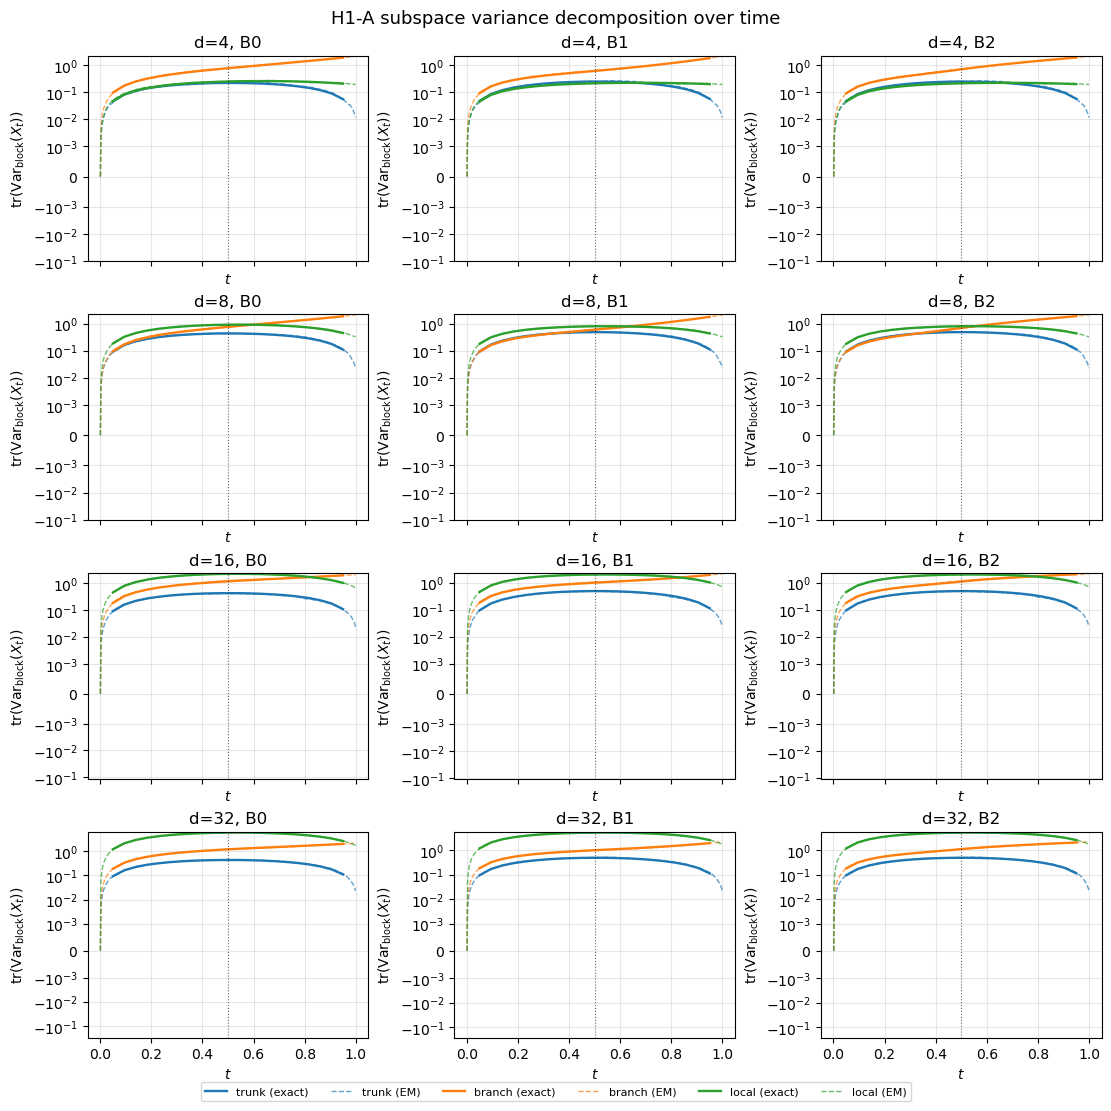

In [12]:
def _plot_subspace_row(axes_row, res, title_prefix=""):
    for ax, name in zip(axes_row, PROTOCOL_NAMES):
        d_pl = res["protocols"][name]
        td = d_pl["subspace_dens_times"]
        te = d_pl["subspace_emp_times"]
        for block, color in [("trunk",  "tab:blue"),
                             ("branch", "tab:orange"),
                             ("local",  "tab:green")]:
            ax.plot(td, d_pl["subspace_dens"][block],
                    color=color, lw=1.7, label=f"{block} (exact)")
            ax.plot(te, d_pl["subspace_emp"][block],
                    color=color, lw=1.0, ls="--", alpha=0.7,
                    label=f"{block} (EM)")
        ax.axvline(T_STAR, color="k", ls=":", lw=0.8, alpha=0.6)
        ax.set_xlabel("$t$")
        ax.set_ylabel(r"$\mathrm{tr}(\mathrm{Var}_{\mathrm{block}}(X_t))$")
        ax.set_title(f"{title_prefix}{name}")
        ax.set_yscale("symlog", linthresh=1e-3)
        ax.grid(True, alpha=0.3)


fig, axes = plt.subplots(len(DIMS_A), 3,
                         figsize=(11.0, 2.7 * len(DIMS_A)),
                         constrained_layout=True, sharex=True)
for i, (d, res) in enumerate(zip(DIMS_A, results_A)):
    _plot_subspace_row(axes[i], res, title_prefix=f"d={d}, ")

# A single legend
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=6, fontsize=8,
           bbox_to_anchor=(0.5, -0.02))
fig.suptitle("H1-A subspace variance decomposition over time", fontsize=13)
fig.savefig(os.path.join(FIGDIR, "H1A_subspace_traces.pdf"),
            bbox_inches="tight")
plt.show()

# H1-B — Mode scaling at fixed dimension

Following the plan's hierarchy
$M=2,4,8,16 \;\Leftrightarrow\; (B,L)=(2,1),(2,2),(4,2),(4,4)$,
we fix $d=16$ and sweep $M$.

In [13]:
MODE_HIERARCHY = {2: (2, 1), 4: (2, 2), 8: (4, 2), 16: (4, 4)}

results_B: List[Dict] = []
for M in M_B:
    Bb, Ll = MODE_HIERARCHY[M]
    print(f"\n[H1-B] d={D_B_FIXED}, M={M}  (B={Bb}, L={Ll})")
    res, _, _, _ = run_single_scenario(
        d=D_B_FIXED, B_branches=Bb, L_locals=Ll,
    )
    results_B.append(res)
    for name in PROTOCOL_NAMES:
        m = res["protocols"][name]["metrics"]
        print(f"  {name}: tv_w={m['tv_weight_err']:.4f}  "
              f"A_guide={m['guide_cost']:.3f}  "
              f"t_brk_emp={m['branch_time_emp']}  "
              f"pre={m['wallclock_precompute_s']:.3f}s  "
              f"sim={m['wallclock_simulate_s']:.3f}s")

save_metrics_json(os.path.join(OUTDIR, "H1B_mode_sweep.json"),
                  {"results": [
                      {**r, "protocols": {
                          k: {"metrics": v["metrics"]}
                          for k, v in r["protocols"].items()
                      }} for r in results_B
                  ]})


[H1-B] d=16, M=2  (B=2, L=1)
  B0: tv_w=0.0391  A_guide=3.378  t_brk_emp=0.17833333333333332  pre=0.046s  sim=1.679s
  B1: tv_w=0.0420  A_guide=3.291  t_brk_emp=0.20166666666666666  pre=0.020s  sim=1.573s
  B2: tv_w=0.0400  A_guide=3.358  t_brk_emp=0.215  pre=0.018s  sim=1.612s

[H1-B] d=16, M=4  (B=2, L=2)
  B0: tv_w=0.0391  A_guide=3.412  t_brk_emp=0.17833333333333332  pre=0.018s  sim=2.045s
  B1: tv_w=0.0420  A_guide=3.320  t_brk_emp=0.20166666666666666  pre=0.021s  sim=1.960s
  B2: tv_w=0.0400  A_guide=3.386  t_brk_emp=0.215  pre=0.020s  sim=1.972s

[H1-B] d=16, M=8  (B=4, L=2)
  B0: tv_w=0.0607  A_guide=3.673  t_brk_emp=0.3916666666666666  pre=0.017s  sim=2.662s
  B1: tv_w=0.0518  A_guide=3.539  t_brk_emp=0.5083333333333333  pre=0.028s  sim=2.635s
  B2: tv_w=0.0575  A_guide=3.647  t_brk_emp=0.46166666666666667  pre=0.019s  sim=2.689s

[H1-B] d=16, M=16  (B=4, L=4)
  B0: tv_w=0.0623  A_guide=3.672  t_brk_emp=0.3916666666666666  pre=0.018s  sim=3.984s
  B1: tv_w=0.0575  A_guide=3.5

## H1-B panels — mode-weight error and guide cost vs $M$

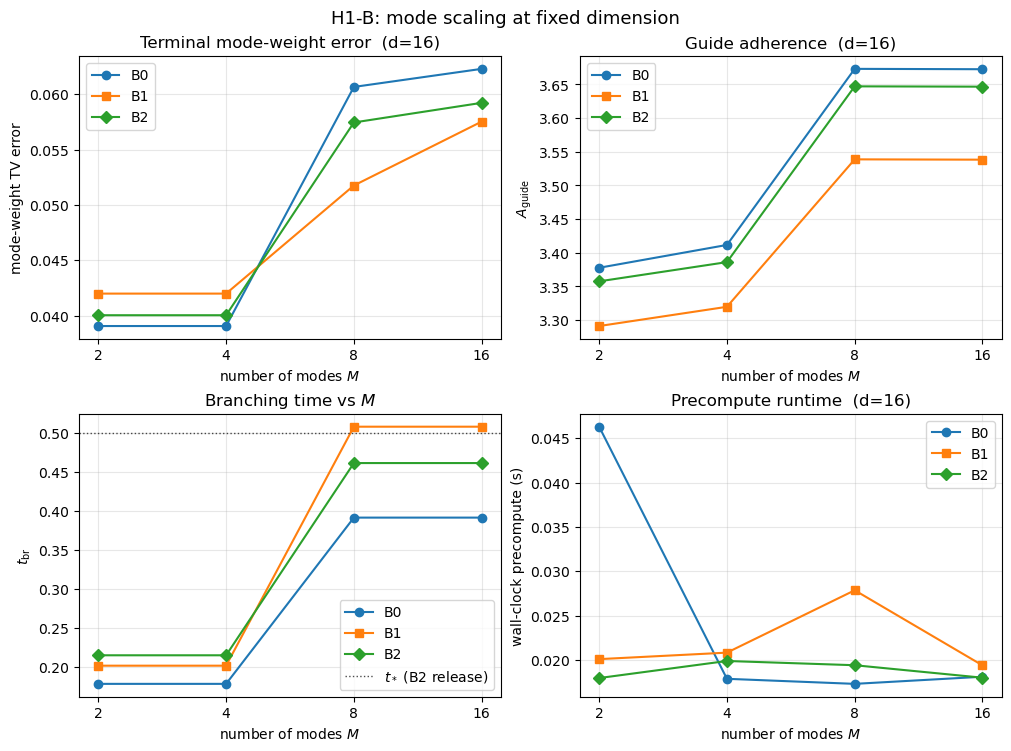

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(10.0, 7.4), constrained_layout=True)
xs = np.array(M_B)

ax = axes[0, 0]
for name, mark in zip(PROTOCOL_NAMES, ["o", "s", "D"]):
    ax.plot(xs, _series(results_B, name, "tv_weight_err"),
            marker=mark, label=name)
ax.set_xscale("log", base=2); ax.set_xticks(xs); ax.set_xticklabels(xs)
ax.set_xlabel("number of modes $M$")
ax.set_ylabel("mode-weight TV error")
ax.set_title(f"Terminal mode-weight error  (d={D_B_FIXED})")
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[0, 1]
for name, mark in zip(PROTOCOL_NAMES, ["o", "s", "D"]):
    ax.plot(xs, _series(results_B, name, "guide_cost"),
            marker=mark, label=name)
ax.set_xscale("log", base=2); ax.set_xticks(xs); ax.set_xticklabels(xs)
ax.set_xlabel("number of modes $M$")
ax.set_ylabel(r"$A_{\mathrm{guide}}$")
ax.set_title(f"Guide adherence  (d={D_B_FIXED})")
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1, 0]
for name, mark in zip(PROTOCOL_NAMES, ["o", "s", "D"]):
    ax.plot(xs, _series(results_B, name, "branch_time_emp"),
            marker=mark, label=name)
ax.axhline(T_STAR, color="k", ls=":", lw=1, alpha=0.7,
           label=r"$t_*$ (B2 release)")
ax.set_xscale("log", base=2); ax.set_xticks(xs); ax.set_xticklabels(xs)
ax.set_xlabel("number of modes $M$")
ax.set_ylabel(r"$t_{\mathrm{br}}$")
ax.set_title("Branching time vs $M$")
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1, 1]
for name, mark in zip(PROTOCOL_NAMES, ["o", "s", "D"]):
    ax.plot(xs, _series(results_B, name, "wallclock_precompute_s"),
            marker=mark, label=f"{name}")
ax.set_xscale("log", base=2); ax.set_xticks(xs); ax.set_xticklabels(xs)
ax.set_xlabel("number of modes $M$")
ax.set_ylabel("wall-clock precompute (s)")
ax.set_title(f"Precompute runtime  (d={D_B_FIXED})")
ax.legend()
ax.grid(True, alpha=0.3)

fig.suptitle("H1-B: mode scaling at fixed dimension", fontsize=13)
fig.savefig(os.path.join(FIGDIR, "H1B_mode_scaling.pdf"))
plt.show()

# H1-C — Representative qualitative views

The plan asks for "one or two selected low-dimensional projections or
PCA projections for intuition only." We pick the central
configuration $(d, M) = (16, 8)$ and protocol B2 (branch-release), and
render two snapshots:

* **Trunk-plane projection** — $(x_1, x_2)$, where the trunk lives;
* **Top-2 PCA projection** — principal components of the empirical
  ensemble at $t=1$, used to project all earlier times.

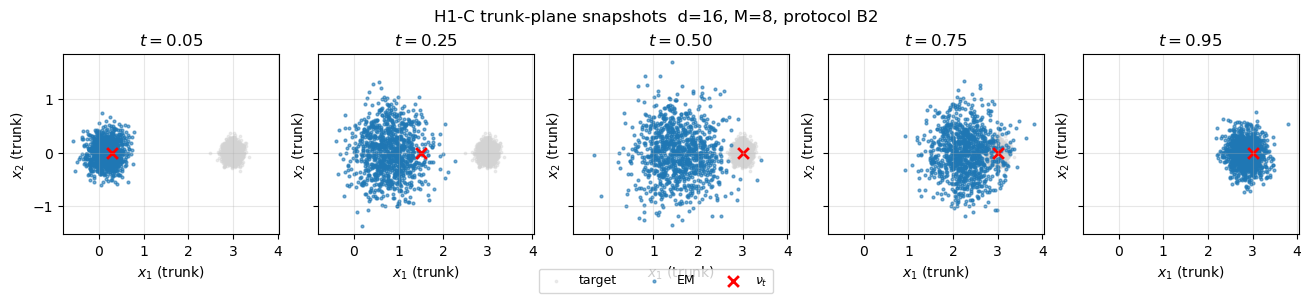

In [15]:
D_C, M_C = 16, 8
B_C, L_C = MODE_HIERARCHY[M_C]
layout_C = make_block_layout(D_C)
target_C, mu_trunk_C = make_hierarchical_target(
    d=D_C, B_branches=B_C, L_locals=L_C, layout=layout_C,
)
breaks_C = make_breaks(K_INTERVALS)
beta_C = make_beta_B2(K_INTERVALS, breaks_C, layout_C)
proto_C = assemble_protocol(layout=layout_C, target=target_C,
                            mu_trunk=mu_trunk_C, beta=beta_C)
pid_C = LQGMPID(protocol=proto_C, target=target_C,
                x0=torch.zeros(D_C, dtype=DTYPE, device=DEVICE),
                bc_eps=BC_EPS).precompute()
times_C, traj_C = simulate_paths(pid_C, B=B_SIM)

# Snapshot times
SNAP_TIMES = [0.05, 0.25, 0.50, 0.75, 0.95]
snap_idx = [int(np.argmin(np.abs(times_C.numpy() - t))) for t in SNAP_TIMES]


def _trunk_panels(traj, snap_idx, target, layout):
    fig, axes = plt.subplots(1, len(snap_idx),
                             figsize=(2.6 * len(snap_idx), 2.8),
                             constrained_layout=True, sharex=True, sharey=True)
    target_samples = sample_gmm_iid(target, 2000, seed=11).cpu()
    for ax, idx in zip(axes, snap_idx):
        ax.scatter(target_samples[:, 0], target_samples[:, 1],
                   c="lightgrey", s=3, alpha=0.4, label="target")
        x = traj[idx, :, 0].numpy()
        y = traj[idx, :, 1].numpy()
        ax.scatter(x, y, c="tab:blue", s=4, alpha=0.6, label="EM")
        # current guide marker
        nu_t = fast_then_hold_guide(times_C[idx:idx+1].to(DTYPE),
                                    mu_trunk_C.cpu()).cpu().numpy()[0]
        ax.scatter([nu_t[0]], [nu_t[1]], c="red", marker="x", s=60, lw=2,
                   label=r"$\nu_t$")
        ax.set_title(f"$t={float(times_C[idx]):.2f}$")
        ax.set_xlabel("$x_1$ (trunk)")
        ax.set_ylabel("$x_2$ (trunk)")
        ax.grid(True, alpha=0.3)
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=3,
               bbox_to_anchor=(0.5, -0.05), fontsize=9)
    fig.suptitle(f"H1-C trunk-plane snapshots  d={D_C}, M={M_C}, protocol B2",
                 fontsize=12)
    return fig


fig_trunk = _trunk_panels(traj_C, snap_idx, target_C, layout_C)
fig_trunk.savefig(os.path.join(FIGDIR, "H1C_trunk_snapshots.pdf"),
                  bbox_inches="tight")
plt.show()

### PCA projection panels

We compute principal components of the empirical terminal ensemble and
project all earlier-time clouds onto the same axes.

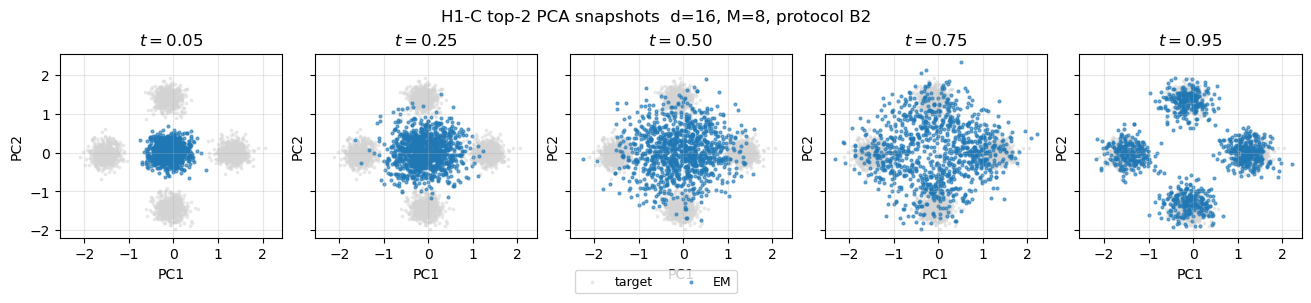

In [16]:
def _pca_panels(traj, snap_idx, target):
    x_T = traj[-1].numpy()
    x_T_centered = x_T - x_T.mean(axis=0, keepdims=True)
    # SVD of the centred terminal cloud
    _, _, Vt = np.linalg.svd(x_T_centered, full_matrices=False)
    P = Vt[:2].T                                             # (d, 2)

    target_samples = sample_gmm_iid(target, 2000, seed=11).cpu().numpy()
    target_proj = (target_samples - x_T.mean(axis=0)) @ P    # (n, 2)

    fig, axes = plt.subplots(1, len(snap_idx),
                             figsize=(2.6 * len(snap_idx), 2.8),
                             constrained_layout=True, sharex=True, sharey=True)
    for ax, idx in zip(axes, snap_idx):
        ax.scatter(target_proj[:, 0], target_proj[:, 1],
                   c="lightgrey", s=3, alpha=0.4, label="target")
        cur = traj[idx].numpy()
        cur_p = (cur - x_T.mean(axis=0)) @ P
        ax.scatter(cur_p[:, 0], cur_p[:, 1],
                   c="tab:blue", s=4, alpha=0.6, label="EM")
        ax.set_title(f"$t={float(times_C[idx]):.2f}$")
        ax.set_xlabel("PC1")
        ax.set_ylabel("PC2")
        ax.grid(True, alpha=0.3)
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=2,
               bbox_to_anchor=(0.5, -0.05), fontsize=9)
    fig.suptitle(f"H1-C top-2 PCA snapshots  d={D_C}, M={M_C}, protocol B2",
                 fontsize=12)
    return fig


fig_pca = _pca_panels(traj_C, snap_idx, target_C)
fig_pca.savefig(os.path.join(FIGDIR, "H1C_pca_snapshots.pdf"),
                bbox_inches="tight")
plt.show()

# Summary tables

Compact CSV-style summary for the paper. One row per $(d, M, \text{protocol})$.

In [17]:
def _flatten(results, scenario_label):
    rows = []
    for r in results:
        for name in PROTOCOL_NAMES:
            m = r["protocols"][name]["metrics"]
            rows.append({
                "scenario": scenario_label,
                "d": r["d"], "M": r["M"],
                "protocol": name,
                "tv_weight_err":   m["tv_weight_err"],
                "linf_weight_err": m["linf_weight_err"],
                "mean_l2_err":     m["mean_l2_error"],
                "guide_cost":      m["guide_cost"],
                "branch_time_emp":  m["branch_time_emp"],
                "branch_time_dens": m["branch_time_dens"],
                "wall_precompute_s": m["wallclock_precompute_s"],
                "wall_simulate_s":   m["wallclock_simulate_s"],
            })
    return rows


rows_all = _flatten(results_A, "H1A") + _flatten(results_B, "H1B")
save_csv(os.path.join(OUTDIR, "H1_summary.csv"), rows_all)
print(f"\nSaved summary CSV with {len(rows_all)} rows -> {OUTDIR}/H1_summary.csv")

# Pretty-print to stdout for the paper
print("\n" + "=" * 86)
print(f"{'scenario':<6}{'d':>4}{'M':>4}{'proto':>7}"
      f"{'tv_w':>10}{'A_guide':>10}{'t_brk':>9}{'pre/s':>8}{'sim/s':>8}")
print("-" * 86)
for r in rows_all:
    tbe = "—" if r["branch_time_emp"] is None else f"{r['branch_time_emp']:.2f}"
    print(f"{r['scenario']:<6}{r['d']:>4}{r['M']:>4}{r['protocol']:>7}"
          f"{r['tv_weight_err']:>10.4f}{r['guide_cost']:>10.3f}{tbe:>9}"
          f"{r['wall_precompute_s']:>8.3f}{r['wall_simulate_s']:>8.3f}")
print("=" * 86)


Saved summary CSV with 24 rows -> /Users/chertkov/Dropbox/Apps/Overleaf/LQ-GM-PID/guided-plus/results/H1_highdim_scaling/H1_summary.csv

scenario   d   M  proto      tv_w   A_guide    t_brk   pre/s   sim/s
--------------------------------------------------------------------------------------
H1A      4   8     B0    0.0194     1.741     0.66   0.054   1.340
H1A      4   8     B1    0.0236     1.777     0.76   0.015   1.289
H1A      4   8     B2    0.0211     1.873     0.66   0.015   1.271
H1A      8   8     B0    0.0248     2.384     0.65   0.014   1.547
H1A      8   8     B1    0.0234     2.384     0.75   0.015   1.540
H1A      8   8     B2    0.0308     2.480     0.65   0.016   1.630
H1A     16   8     B0    0.0607     3.673     0.39   0.020   2.851
H1A     16   8     B1    0.0518     3.539     0.51   0.024   2.724
H1A     16   8     B2    0.0575     3.647     0.46   0.021   2.657
H1A     32   8     B0    0.0460     6.314     0.42   0.033   5.951
H1A     32   8     B1    0.0455     

# Discussion (notebook-internal)

The four scientific questions posed by the plan map directly onto the
results above:

1. **Does a simple fixed guide remain useful as ambient dimension
   increases?** — H1-A panels report TV error and guide cost as
   functions of $d$; relatively flat curves at fixed protocol indicate
   that the trunk guide $\nu_t$ continues to organize transport in
   high $d$.
2. **Does matrix-valued $\beta_t$ provide a meaningful corridor
   analogue?** — The gap between B0 and B1/B2 in guide cost and
   subspace traces measures the value of *anisotropic* confinement.
3. **Can branch-release scheduling improve modal allocation?** — The
   branching-time statistic should be near $t_*=0.5$ for B2 and
   earlier for B0/B1; B2's mode-weight error should be no worse than
   B0's despite delaying branching.
4. **Does the method continue to separate coarse branching from fine
   local resolution as $M$ grows?** — H1-B panels track this; the
   subspace decomposition figure makes the coarse-to-fine separation
   explicit (trunk variance plateaus by $t_*$, branch variance opens
   up after $t_*$, local variance opens up later still).

Quantitative interpretation will be filled in once the notebook has
been run and the numbers in the summary table are read off.

In [18]:
print("\nH1 notebook complete.")
print(f"Figures: {FIGDIR}/H1A_dimension_scaling.pdf")
print(f"         {FIGDIR}/H1A_subspace_traces.pdf")
print(f"         {FIGDIR}/H1B_mode_scaling.pdf")
print(f"         {FIGDIR}/H1C_trunk_snapshots.pdf")
print(f"         {FIGDIR}/H1C_pca_snapshots.pdf")
print(f"Results: {OUTDIR}/H1A_dimension_sweep.json")
print(f"         {OUTDIR}/H1B_mode_sweep.json")
print(f"         {OUTDIR}/H1_summary.csv")


H1 notebook complete.
Figures: /Users/chertkov/Dropbox/Apps/Overleaf/LQ-GM-PID/guided-plus/figs/H1A_dimension_scaling.pdf
         /Users/chertkov/Dropbox/Apps/Overleaf/LQ-GM-PID/guided-plus/figs/H1A_subspace_traces.pdf
         /Users/chertkov/Dropbox/Apps/Overleaf/LQ-GM-PID/guided-plus/figs/H1B_mode_scaling.pdf
         /Users/chertkov/Dropbox/Apps/Overleaf/LQ-GM-PID/guided-plus/figs/H1C_trunk_snapshots.pdf
         /Users/chertkov/Dropbox/Apps/Overleaf/LQ-GM-PID/guided-plus/figs/H1C_pca_snapshots.pdf
Results: /Users/chertkov/Dropbox/Apps/Overleaf/LQ-GM-PID/guided-plus/results/H1_highdim_scaling/H1A_dimension_sweep.json
         /Users/chertkov/Dropbox/Apps/Overleaf/LQ-GM-PID/guided-plus/results/H1_highdim_scaling/H1B_mode_sweep.json
         /Users/chertkov/Dropbox/Apps/Overleaf/LQ-GM-PID/guided-plus/results/H1_highdim_scaling/H1_summary.csv
